In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl  # 引入底层的画图配置工具
import numpy as np
import pandas as pd
import scanpy as sc

# 1. 设置 Scanpy 日志级别
sc.settings.verbosity = 3
sc.logging.print_header()

# 2. 替代原本报错的 sc.set_figure_params
# 我们直接用 matplotlib 设置图片清晰度和背景，完美绕过报错！
mpl.rcParams['figure.dpi'] = 80
mpl.rcParams['figure.facecolor'] = 'white'

# 3. 设置游戏保存点
results_file = "/root/downloads/data/pbmc3k.h5ad"

# 4. 载入数据
adata = sc.datasets.pbmc3k()

scanpy==1.10.4 anndata==0.10.9 umap==0.5.12 numpy==1.26.4 scipy==1.12.0 pandas==3.0.3 scikit-learn==1.9.0 statsmodels==0.14.6 igraph==1.0.0 leidenalg==0.12.0 pynndescent==0.6.0


In [23]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

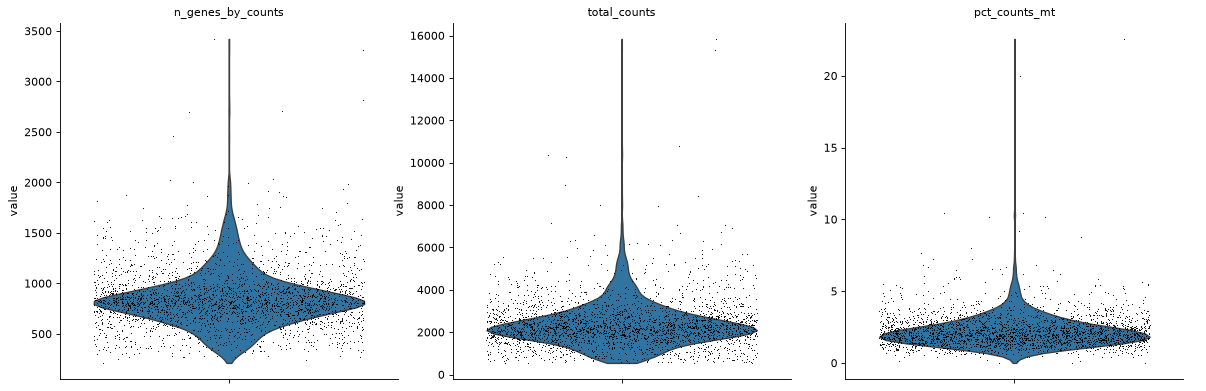

filtered out 19082 genes that are detected in less than 3 cells


/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [2]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None,log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
#过滤少于200或多于2500的细胞
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
#过滤线粒体比例高于5%的死细胞
adata = adata[adata.obs.pct_counts_mt < 5, :]
#过滤少于3个细胞中表达的基因
sc.pp.filter_genes(adata, min_cells=3)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes


    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


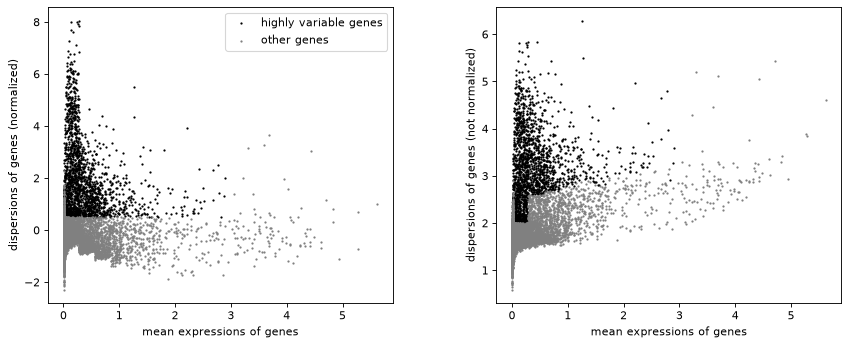

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/root/miniconda3/envs/single_cell/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:672: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:07)


In [3]:
#统一每个细胞测序深度
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

computing PCA
    with n_comps=50


    finished (0:02:48)


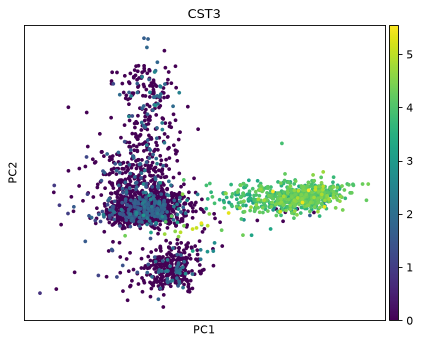

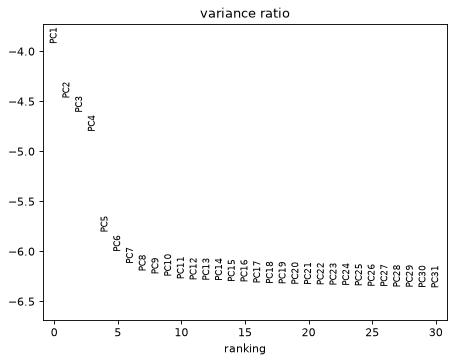

In [4]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca(adata, color='CST3')
sc.pl.pca_variance_ratio(adata, log=True)

computing neighbors
    using 'X_pca' with n_pcs = 10
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:10)
running Leiden clustering


/tmp/ipykernel_139319/2383786346.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    finished: found 13 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


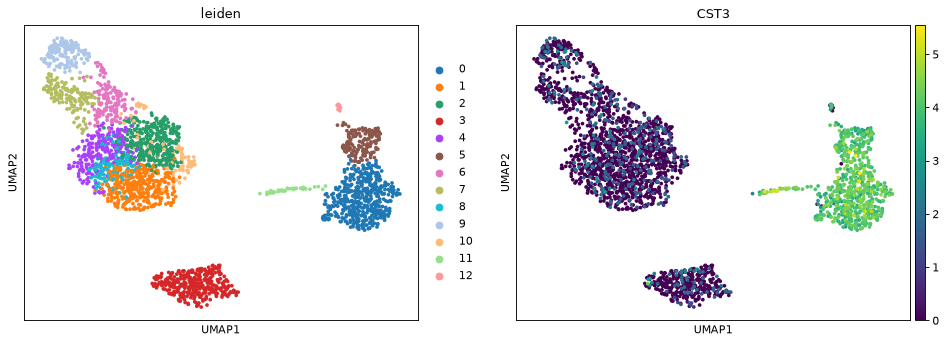

In [5]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=['leiden', 'CST3'])


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


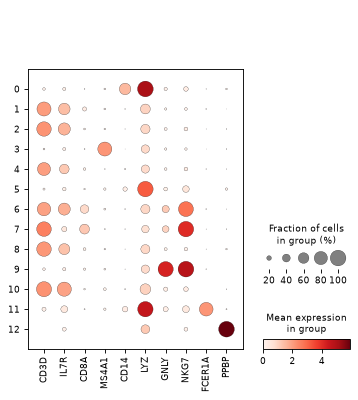

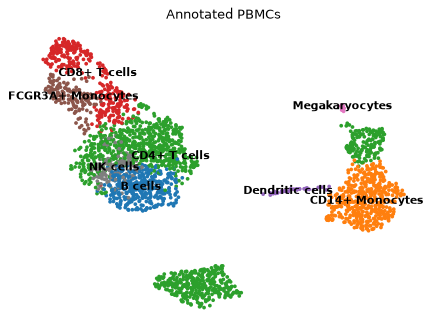

IORegistryError: No method registered for writing <class 'pandas.arrays.StringArray'> into <class 'h5py._hl.group.Group'>

In [9]:
# 1. 计算每个群的差异表达基因
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# 2. 绘制 Marker 基因气泡图
marker_genes = ['CD3D', 'IL7R', 'CD8A', 'MS4A1', 'CD14', 'LYZ', 'GNLY', 'NKG7', 'FCER1A', 'PPBP']
sc.pl.dotplot(adata, marker_genes, groupby='leiden')

# 3. 建立 13 个群到 8 种细胞类型的映射字典
cell_type_map = {
    '0': 'CD14+ Monocytes',
    '1': 'B cells',
    '2': 'CD4+ T cells',
    '3': 'CD4+ T cells',
    '4': 'CD4+ T cells',
    '5': 'CD4+ T cells',
    '6': 'CD8+ T cells',
    '7': 'FCGR3A+ Monocytes',
    '8': 'NK cells',
    '9': 'CD8+ T cells',
    '10': 'CD4+ T cells',
    '11': 'Dendritic cells',
    '12': 'Megakaryocytes'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map).astype('category')

# 这样画出来的星空图上就是合并好、写着英文名称的 8 大类免疫细胞了！
sc.pl.umap(adata, color='cell_type', legend_loc='on data', title='Annotated PBMCs', frameon=False)

adata.write(results_file)

In [20]:
print("你数据里实际被分出来的群：", list(adata.obs['leiden'].cat.categories))
print("实际群的总数量：", len(adata.obs['leiden'].cat.categories))

你数据里实际被分出来的群： ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
实际群的总数量： 13
